\begin{align*}
  f(x) &= x^2\\
  g(x) &= \frac{1}{x}\\
  F(x) &= \int^a_b \frac{1}{3}x^3
\end{align*}

In [ ]:
%matplotlib tk
import matplotlib.pyplot as plt
import matplotlib.animation
import numpy as np

t = np.linspace(0,2*np.pi)
x = np.sin(t)

fig, ax = plt.subplots()
l, = ax.plot([0,2*np.pi],[-1,1])

animate = lambda i: l.set_data(t[:i], x[:i])

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(t))

plt.show()

: 

In [66]:
import scipy as sc
import numpy as np
import sympy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal


In [126]:
def Energy(n):
    return n + 0.5

def dSdt(S,x):
    psi, psip = S
    return [psip,
             -2*Energy(0)*psi + x**2*psi]

psi0 = 1e-20
psip0 = 1e-20
S0 = (psi0, psip0)

In [127]:
N = 10000
x = np.linspace(-10, 10, N)
sol = sc.integrate.odeint(dSdt, S0, x)
psi = sol.T[0]

#plt.plot(x,psi)

In [128]:
dx = np.diff(x)[0]

main_diag = 2*np.ones(N)/dx**2 + 0.5*x**2
main_diag[0] -= 1/dx**2 
main_diag[-1] -= 1/dx**2 
off_diag = -np.ones(N-1)/dx**2

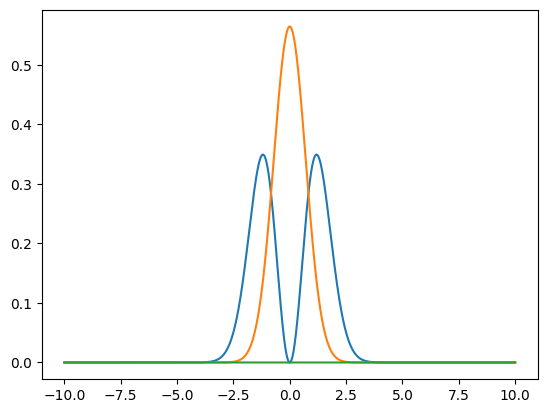

In [130]:
En, psis = eigh_tridiagonal(main_diag, off_diag, False, select = 'v', select_range = (0, 10))

psiSol = np.pi**(-1/4)*np.exp(-x**2/2)

A0 = (np.trapz(np.abs(psis.T[1]**2), x=x))**(-0.5)
psis.T[1] = A0*psis.T[1]

plt.plot(x, np.abs(psis.T[1]**2))
#plt.plot(x, np.abs(psis.T[1]**2))
#plt.plot(x, np.abs(psis.T[2]**2))
#plt.plot(x, np.abs(psis.T[3]**2))

plt.plot(x, psiSol**2)
plt.plot(x,psi**2)